# LAB | Feature Engineering

**Load the data**

In this challenge, we will be working with the same Spaceship Titanic data, like the previous Lab. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Check the shape of your data**

In [3]:
spaceship.shape

(8693, 14)

**Check for data types**

In [4]:
spaceship.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

**Check for missing values**

In [5]:
spaceship.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value. 

In [6]:
# Create a copy to avoid changing the original dataframe
df_drop_rows = spaceship.copy()

# Drop rows where ANY column has a missing value
df_drop_rows = df_drop_rows.dropna()

print(f"Original shape: {spaceship.shape}")
print(f"Shape after dropping rows: {df_drop_rows.shape}")

df_drop_cols = spaceship.copy()

# Drop columns (axis=1) that contain missing values
df_drop_cols = df_drop_cols.dropna(axis=1)

print(f"Shape after dropping columns: {df_drop_cols.shape}")

df_fill_static = spaceship.copy()

# 1. Separate numeric and categorical columns
numeric_cols = df_fill_static.select_dtypes(include=[np.number]).columns
categorical_cols = df_fill_static.select_dtypes(exclude=[np.number]).columns

# 2. Fill Numeric columns with the MEAN
# (You can also use .median() if there are outliers)
for col in numeric_cols:
    mean_val = df_fill_static[col].mean()
    df_fill_static[col] = df_fill_static[col].fillna(mean_val)

# 3. Fill Categorical columns with the MODE (most frequent value)
for col in categorical_cols:
    # mode() returns a series, so we take the first element [0]
    mode_val = df_fill_static[col].mode()[0]
    df_fill_static[col] = df_fill_static[col].fillna(mode_val)

print("Missing values after static filling:")
print(df_fill_static.isnull().sum().sum()) # Should be 0

Original shape: (8693, 14)
Shape after dropping rows: (6606, 14)
Shape after dropping columns: (8693, 2)
Missing values after static filling:
0


C:\Users\safin\AppData\Local\Temp\ipykernel_38676\4114698662.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_fill_static[col] = df_fill_static[col].fillna(mode_val)


- **Cabin** is too granular - transform it in order to obtain {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'}

In [7]:
# 1. Fill missing 'Cabin' values with a placeholder to prevent errors during splitting
spaceship['Cabin'] = spaceship['Cabin'].fillna('Unknown/0/Unknown')

# 2. Extract the 'Deck' (the first letter)
spaceship['Deck'] = spaceship['Cabin'].str.split('/').str[0]

# 3. Check if 'Unknown' decks were created and turn them back to NaN (optional, but good for imputation later)
# Or we can treat 'Unknown' as a valid category. Let's treat 'Unknown' as NaN to fill it properly in Step 4.
spaceship['Deck'] = spaceship['Deck'].replace('Unknown', np.nan)

- Drop PassengerId and Name

In [8]:
cols_to_drop = ['PassengerId', 'Name', 'Cabin']
spaceship = spaceship.drop(columns=cols_to_drop)

- For non-numerical columns, do dummies.

In [10]:
# Separate columns by type
numeric_cols = spaceship.select_dtypes(include=[np.number]).columns
categorical_cols = spaceship.select_dtypes(exclude=[np.number]).columns

# 1. Fill Numeric columns with MEDIAN
for col in numeric_cols:
    spaceship[col] = spaceship[col].fillna(spaceship[col].median())

# 2. Fill Categorical columns with MODE (most frequent value)
for col in categorical_cols:
    if spaceship[col].isnull().sum() > 0:
        mode_val = spaceship[col].mode()[0]
        spaceship[col] = spaceship[col].fillna(mode_val)

# Verify no missing values remain
print(f"Total missing values: {spaceship.isnull().sum().sum()}")
# Output must be 0

# drop_first=True prevents multicollinearity
spaceship = pd.get_dummies(spaceship, drop_first=True)

Total missing values: 0


**Perform Train Test Split**

In [11]:
X = spaceship.drop('Transported', axis=1)
y = spaceship['Transported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model Selection**

In this exercise we will be using **KNN** as our predictive model.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler()

# Fit on Train, Transform on Train and Test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.7780


- Evaluate your model's performance. Comment it

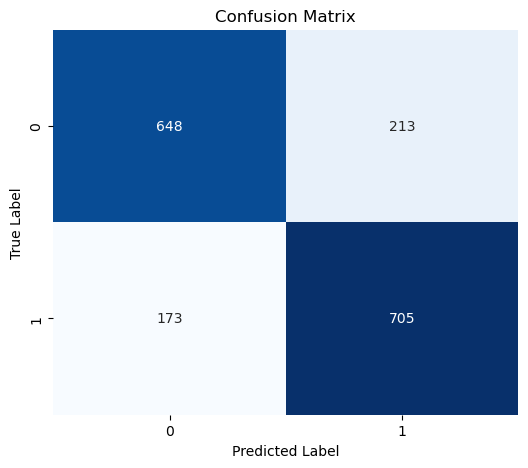


Classification Report:

              precision    recall  f1-score   support

       False       0.79      0.75      0.77       861
        True       0.77      0.80      0.79       878

    accuracy                           0.78      1739
   macro avg       0.78      0.78      0.78      1739
weighted avg       0.78      0.78      0.78      1739



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the Confusion Matrix using a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print the detailed Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Comment: This is a decent baseline, but for the Spaceship Titanic dataset, it is slightly underperforming. Top models often reach ~80%.